Regression Tree Implementation


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor as SKDecisionTreeRegressor
from sklearn.metrics import mean_squared_error

Define the Tree Structures


In [3]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None

class RegressionTree:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._build_tree(X, y)

    def _build_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape

        # Stopping criteria
        if (depth >= self.max_depth or
            n_samples < self.min_samples_split or
            np.all(y == y[0])):
            leaf_value = np.mean(y)
            return Node(value=leaf_value)

        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)

        # Find the best split
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        # If no split improves the variance, return a leaf
        if best_feat is None:
            return Node(value=np.mean(y))

        # Create child nodes
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._build_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._build_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y, feat_idxs):
        best_variance_reduction = -1
        split_idx, split_thresh = None, None
        parent_variance = np.var(y) * len(y)

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for thresh in thresholds:
                left_idxs, right_idxs = self._split(X_column, thresh)
                if len(left_idxs) == 0 or len(right_idxs) == 0:
                    continue

                # Calculate weighted variance of children
                n_l, n_r = len(left_idxs), len(right_idxs)
                var_l, var_r = np.var(y[left_idxs]), np.var(y[right_idxs])
                child_variance = (n_l * var_l) + (n_r * var_r)

                variance_reduction = parent_variance - child_variance
                if variance_reduction > best_variance_reduction:
                    best_variance_reduction = variance_reduction
                    split_idx = feat_idx
                    split_thresh = thresh

        return split_idx, split_thresh

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

Generate Dataset and Train Models


In [4]:
# Generate synthetic dataset
X, y = make_regression(n_samples=200, n_features=1, noise=15.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate and fit our custom tree
custom_tree = RegressionTree(max_depth=5, min_samples_split=5)
custom_tree.fit(X_train, y_train)

# Instantiate and fit scikit-learn's tree
sk_tree = SKDecisionTreeRegressor(max_depth=5, min_samples_split=5, random_state=42)
sk_tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_split=5, random_state=42)

Evaluate and Visualize Results


Custom Tree Test MSE: 380.0967
scikit-learn Tree Test MSE: 390.9813


/tmp/ipykernel_2992/4284017080.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


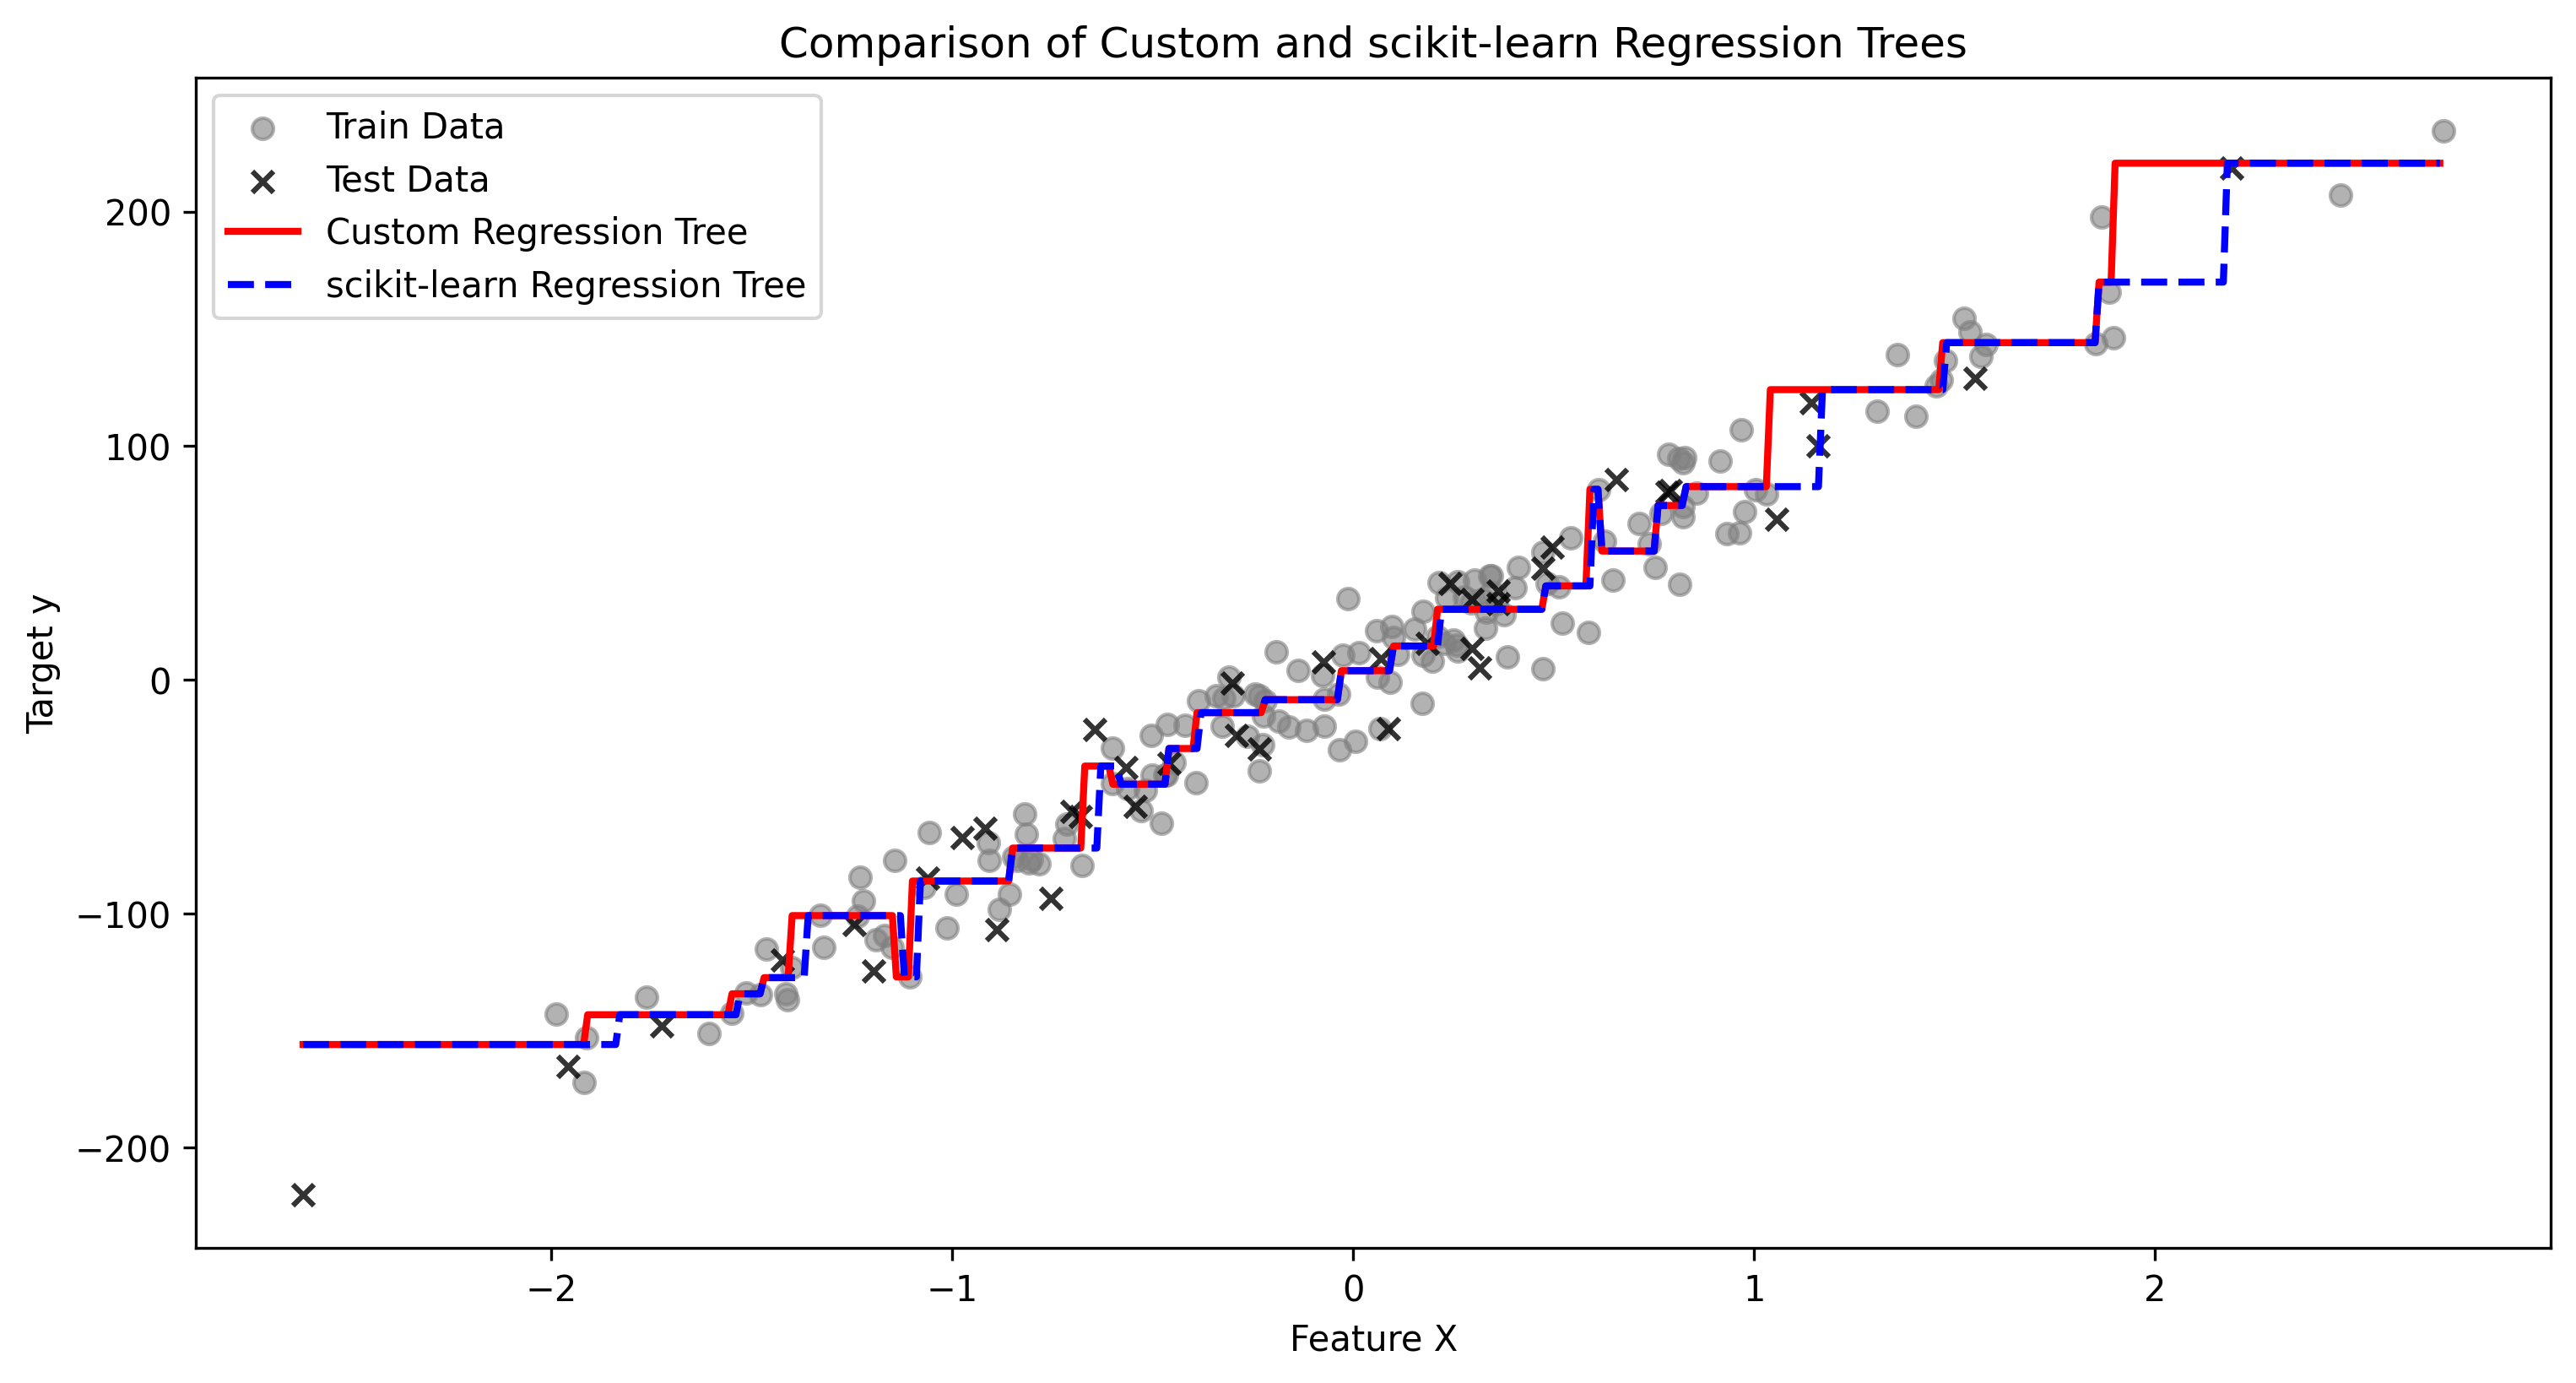

In [5]:
# Predict
custom_preds = custom_tree.predict(X_test)
sk_preds = sk_tree.predict(X_test)

# Evaluate performance
print(f"Custom Tree Test MSE: {mean_squared_error(y_test, custom_preds):.4f}")
print(f"scikit-learn Tree Test MSE: {mean_squared_error(y_test, sk_preds):.4f}")

# Visualization setup
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)
custom_grid_preds = custom_tree.predict(X_grid)
sk_grid_preds = sk_tree.predict(X_grid)

# Plot
plt.figure(figsize=(12, 6), dpi=300)
plt.scatter(X_train, y_train, color='gray', alpha=0.6, label='Train Data')
plt.scatter(X_test, y_test, color='black', alpha=0.8, marker='x', label='Test Data')
plt.plot(X_grid, custom_grid_preds, color='red', linewidth=2, label='Custom Regression Tree')
plt.plot(X_grid, sk_grid_preds, color='blue', linestyle='--', linewidth=2, label='scikit-learn Regression Tree')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.title('Comparison of Custom and scikit-learn Regression Trees')
plt.legend()
plt.show()